## Load partition files, imports, and style

In [26]:
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA

OUT = Path('figures')
OUT.mkdir(exist_ok=True)
print('Output directory:', OUT.resolve())

Output directory: C:\Users\taoni\Documents\jc\figures


In [27]:
# Load partition files
partition_names = ['louvain', 'greedy', 'greedy_bestn', 'hybrid_optimized', 'qpu_optimized']
method_labels   = ['Louvain', 'Greedy', 'Greedy (best_n)', 'Hybrid', 'QPU']

partitions = {}
for name, label in zip(partition_names, method_labels):
    path = Path(f'partitions/partition_{name}.json')
    if path.exists():
        with open(path) as f:
            partitions[label] = np.array(json.load(f))
        print(f'Loaded {label}: {len(np.unique(partitions[label]))} communities')
    else:
        print(f'WARNING: {path} not found')

# Load graph and adjacency matrix
G = nx.read_graphml('neuronal_graphs/neurons10.graphml')
G.remove_nodes_from(list(nx.isolates(G)))
G_undirected = G.to_undirected()
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))
A = nx.adjacency_matrix(G_undirected, weight=None).toarray().astype(float)
N = G_undirected.number_of_nodes()
print(f'Graph: {N} nodes, {G_undirected.number_of_edges()} edges')

# Load location data
locations = pd.read_csv('neuron_locations.csv', header=None, names=['x', 'y', 'z'])

Loaded Louvain: 52 communities
Loaded Greedy: 29 communities
Loaded Greedy (best_n): 8 communities
Loaded Hybrid: 8 communities
Loaded QPU: 8 communities
Graph: 77 nodes, 48 edges


### compute statistics from partitions

In [39]:
def compute_modularity(partition, A):
    degrees = A.sum(axis=1)
    m = A.sum() / 2.0
    Q = 0.0
    for i in range(len(partition)):
        for j in range(len(partition)):
            if partition[i] == partition[j]:
                Q += A[i, j] - (degrees[i] * degrees[j]) / (2.0 * m)
    return Q / (2.0 * m)

def compute_conductance(partition, A):
    degrees = A.sum(axis=1)
    conductances = []
    for community_id in np.unique(partition):
        S  = np.where(partition == community_id)[0]
        if len(S) <= 1:
            continue
        Sc = np.where(partition != community_id)[0]
        if len(Sc) == 0:
            continue
        cut   = A[np.ix_(S, Sc)].sum()
        vol_S = degrees[S].sum()
        vol_c = degrees[Sc].sum()
        denom = min(vol_S, vol_c)
        if denom > 0:
            conductances.append(cut / denom)
    singleton_count = 0
    double_count = 0
    for community_id in np.unique(partition):
        S = np.where(partition == community_id)[0]
        if len(S) == 1:
            singleton_count += 1  # Max conductance for single-node communities
        if len(S) == 2:
            double_count += 1  # Max conductance for two-node communities
    return (np.mean(conductances)+(singleton_count/77)+(double_count/(77*2))) if conductances else np.nan


def method_stats(partitions_dict, A):
    rows = []
    for label, p in partitions_dict.items():
        rows.append({
            'Method': label,
            'Modularity': compute_modularity(p, A),
            'Conductance': compute_conductance(p, A),
            'Communities': len(np.unique(p)),
        })
    return pd.DataFrame(rows)

stats = method_stats(partitions, A)
print(stats.to_string(index=False))

         Method  Modularity  Conductance  Communities
        Louvain    0.488281     0.688023           52
         Greedy    0.950521     0.123377           29
Greedy (best_n)    0.267361     0.045455            8
         Hybrid    0.803168     0.057921            8
            QPU    0.825521     0.006494            8


In [55]:
plt.rcParams.update({
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     13,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'axes.linewidth':     0.8,
    'xtick.major.width':  0.8,
    'ytick.major.width':  0.8,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.dpi':         300,
    'savefig.dpi':        300,
})


## Figures

### Modularity

findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font family 'Serif' not found.
findfont: Font f

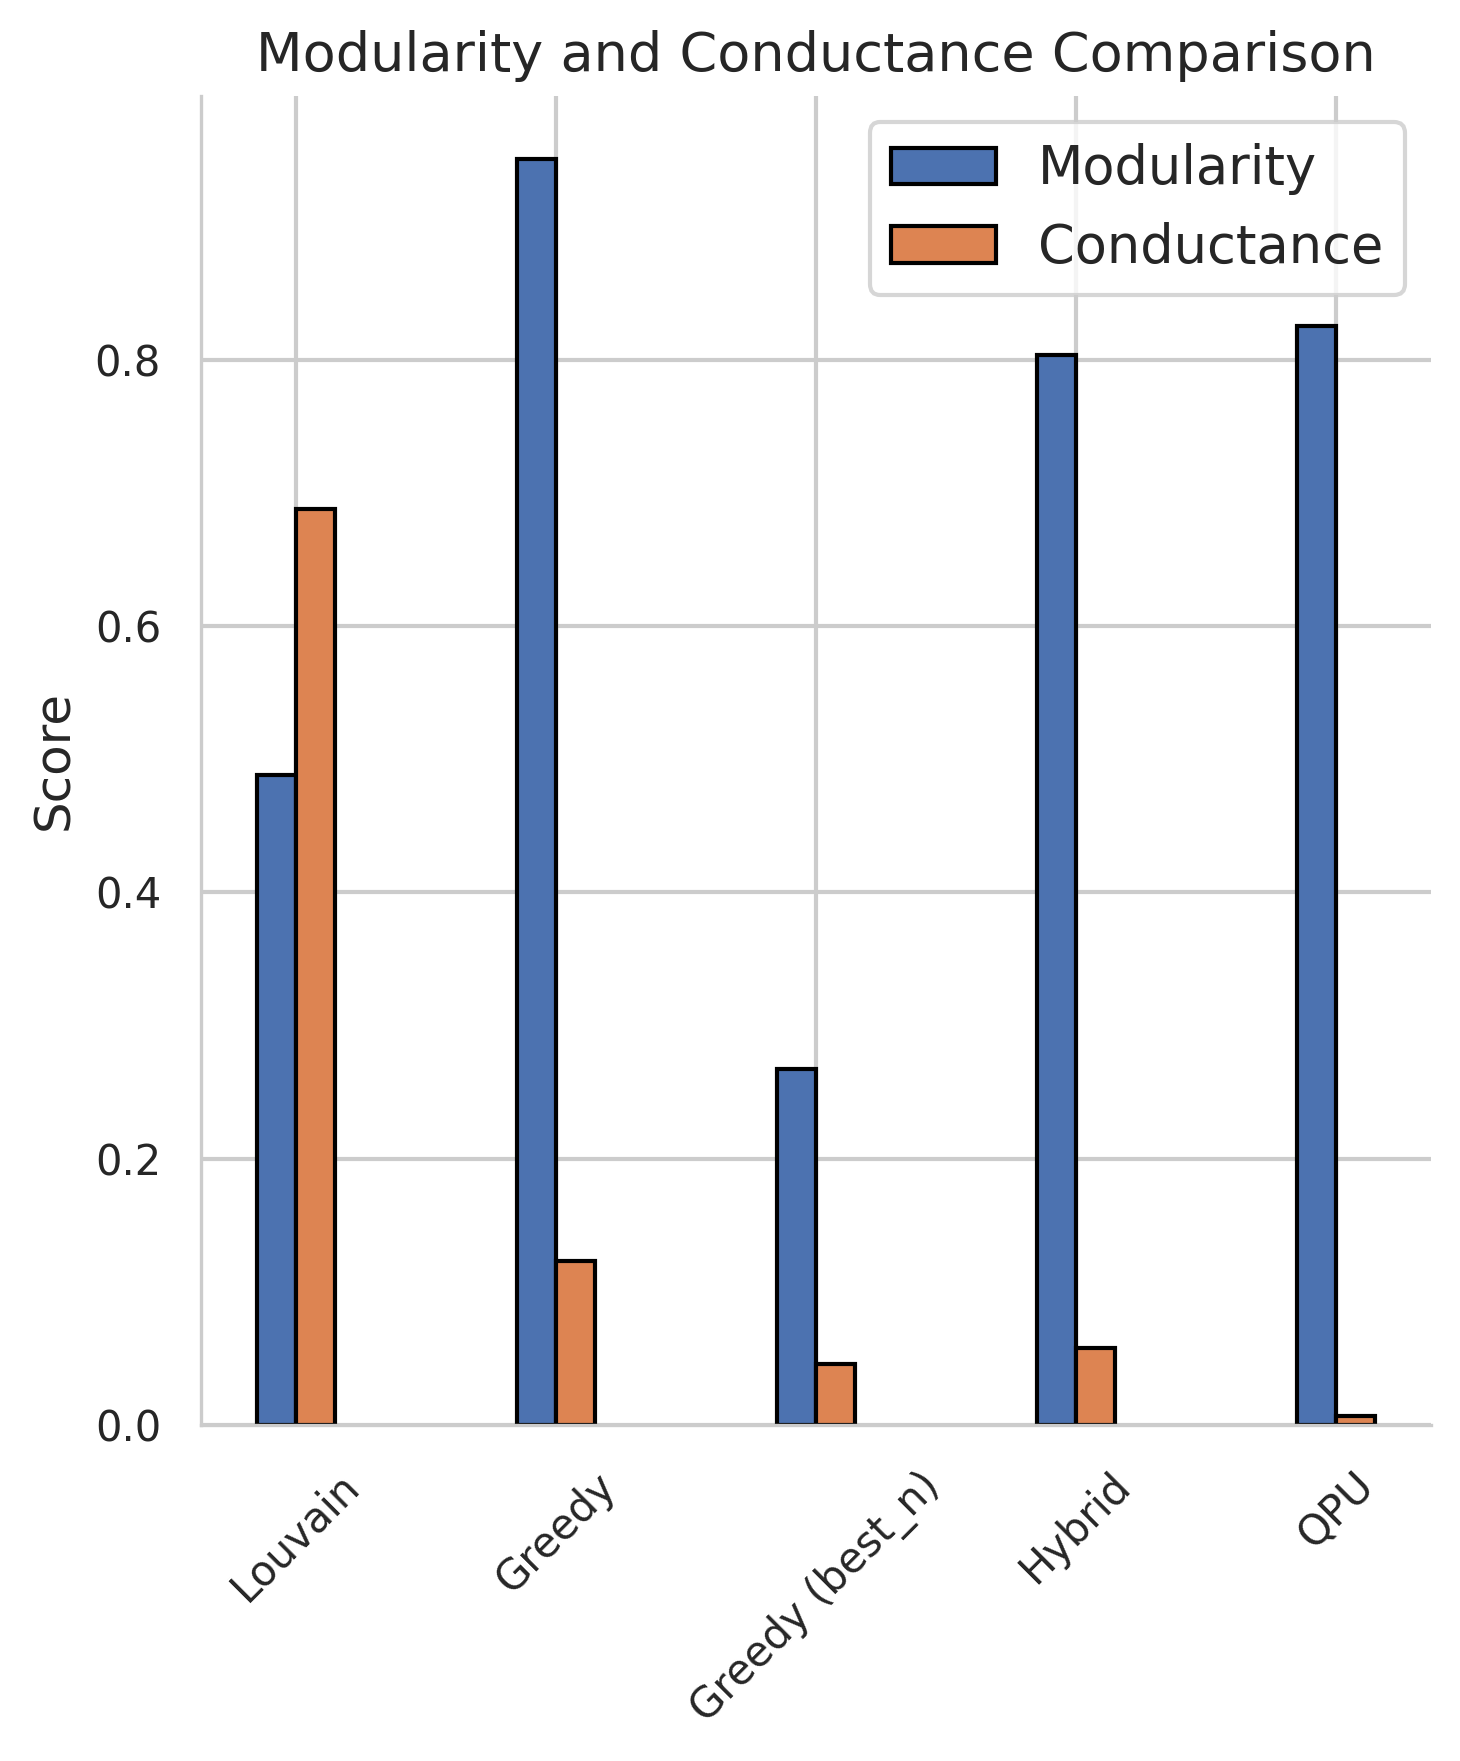

In [63]:
methods = stats['Method']
modularity = stats['Modularity']
conductance = stats['Conductance']

x = np.arange(len(methods))
width = 0.15  # width of the bars

fig, ax = plt.subplots(figsize=(5, 6))
bar1 = ax.bar(x - width/2, modularity, width, label='Modularity', edgecolor='black', linewidth=1)
bar2 = ax.bar(x + width/2, conductance, width, label='Conductance', edgecolor='black', linewidth=1)

ax.set_ylabel('Score')
ax.set_title('Modularity and Conductance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'fig1_modularity_conductance_comparison.png', bbox_inches='tight')
plt.show()

### 3D Scatterplot

Text(0.5, 0, 'Z')

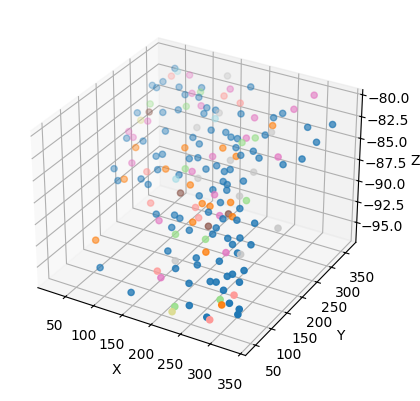

In [32]:
# List of non-pruned neurons
neurons = ["3","5","6","7","10","12","13","14","15","17","19",
           "21","26","27",
           "30","32","33","34","35","36","37",
           "41","42","43","45","47","48",
           "50","51","52","57","58",
           "61","66",
           "70","72","76",
           "84","85","87","88",
           "90","93","94","95","97","99",
           "102","104","106",
           "111","113","114","115","118",
           "120","126","128",
           "133","139",
           "140","142","144","148","149",
           "150","153","154","156","158",
           "163","164","165","166","167","168","169"]

# Read the file content as a string
partition_json = Path('partitions/partition_qpu_optimized.json')
jsonStr = partition_json.read_text()
partition = np.array(json.loads(jsonStr))

# Adding pruned neurons to partition
communities = np.zeros(172)

for p in range(len(partition)):
    idx = int(neurons[p])
    communities[idx] = partition[p] + 1

# Grey out pruned neurons
num_colors = int(np.max(communities))
cmap = plt.colormaps.get_cmap('tab20')
cmap.set_under(color='lightgrey')  # Set color for pruned neurons (0)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(locations['x'], locations['y'], locations['z'], c=communities, cmap=cmap, marker='o')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# plt.savefig(OUT / 'fig2_3d_scatter_{}.png', bbox_inches='tight')

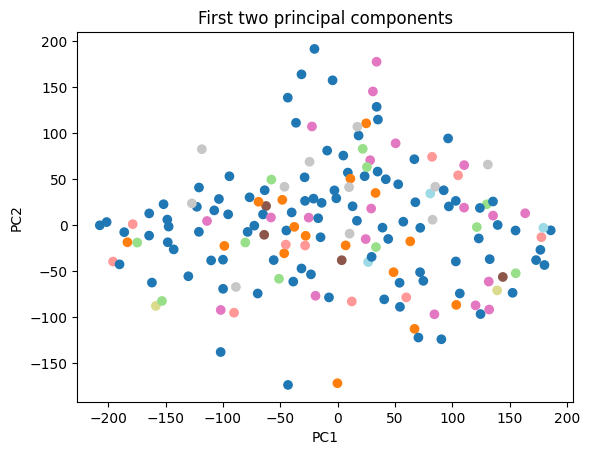

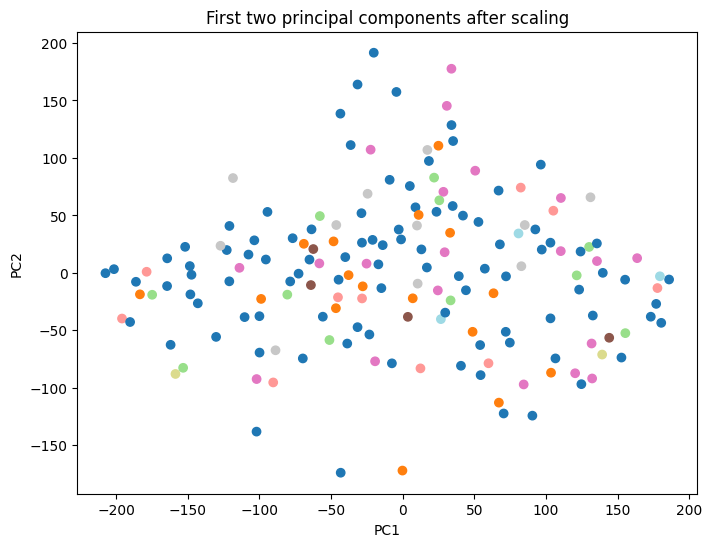

In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Dimensionality reduction 3D to 2D for visualization
data_3d = locations[['x', 'y', 'z']].values
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_3d)
plot = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=communities, cmap='tab20', marker='o')
# plt.legend(handles=plot.legend_elements()[0], labels=communities)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("First two principal components")
plt.show()

# Show first two principal components with scaler
pca = PCA(n_components=2)
pipe = Pipeline([('scaler', StandardScaler()), ('pca', pca)])
plt.figure(figsize=(8,6))
data_2d = pca.fit_transform(data_3d)
plot = plt.scatter(data_2d[:,0], data_2d[:,1], c=communities, cmap='tab20', marker='o')
# plt.legend(handles=plot.legend_elements()[0], labels=communities)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("First two principal components after scaling")
plt.show()

### Neuronal Networks

### Graph Partitioning